In [1]:

import numpy as np
import pandas as pd
from numpy import random
import os
os.getcwd()     #get current working directory
os.chdir("/content/drive/MyDrive")
os.getcwd
df=pd.read_excel('CDAC_DataBook (1).xlsx',sheet_name='ERPData')
df.head()       #by default 5 rows ahe shown
import scipy
from scipy import stats
from scipy.stats import norm,t
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import expon



import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot,show,title,xlabel,ylabel


import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp


import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest

from statsmodels.stats import rates

from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f

import sklearn

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import log_loss

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_auc_score
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_excel('CDAC_DataBook (1).xlsx', sheet_name = 'diabetes')
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]

diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df = df.drop('DietType', axis=1)
df = pd.concat([df,diet_dummy], axis=1)

x= df.drop('Outcome', axis=1)  # column of predictors
y= df.Outcome   # column of response


In [3]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)


DecisionTreeClassifier()

In [4]:

y_pred=dtc.predict(x_test)

In [5]:
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy


[[86 15]
 [15 38]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       101
           1       0.72      0.72      0.72        53

    accuracy                           0.81       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.81      0.81      0.81       154

1.0
0.8051948051948052


In [6]:
# hyperparameter tuning

param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [2,3,4,5]
}

In [7]:

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3360 fits failed out of a total of 10080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3360 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/

{'criterion': 'gini',
 'max_depth': 7,
 'max_features': 'log2',
 'min_samples_leaf': 3,
 'min_samples_split': 5,
 'splitter': 'random'}

In [8]:
dtc = DecisionTreeClassifier(criterion= 'gini',
 max_depth= 7,
 max_features= 'log2',
 min_samples_leaf= 3,
 min_samples_split= 5,
 splitter= 'best')

In [9]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=7, max_features='log2', min_samples_leaf=3,
                       min_samples_split=5)

In [10]:
print(dtc.score(x_train, y_train))   # training data accuracy

0.8843648208469055


In [11]:
print(dtc.score(x_test, y_test))    # test data accuracy


0.7857142857142857


In [12]:
y_pred = dtc.predict(x_test)
print(confusion_matrix(y_test,y_pred))

[[84 17]
 [16 37]]


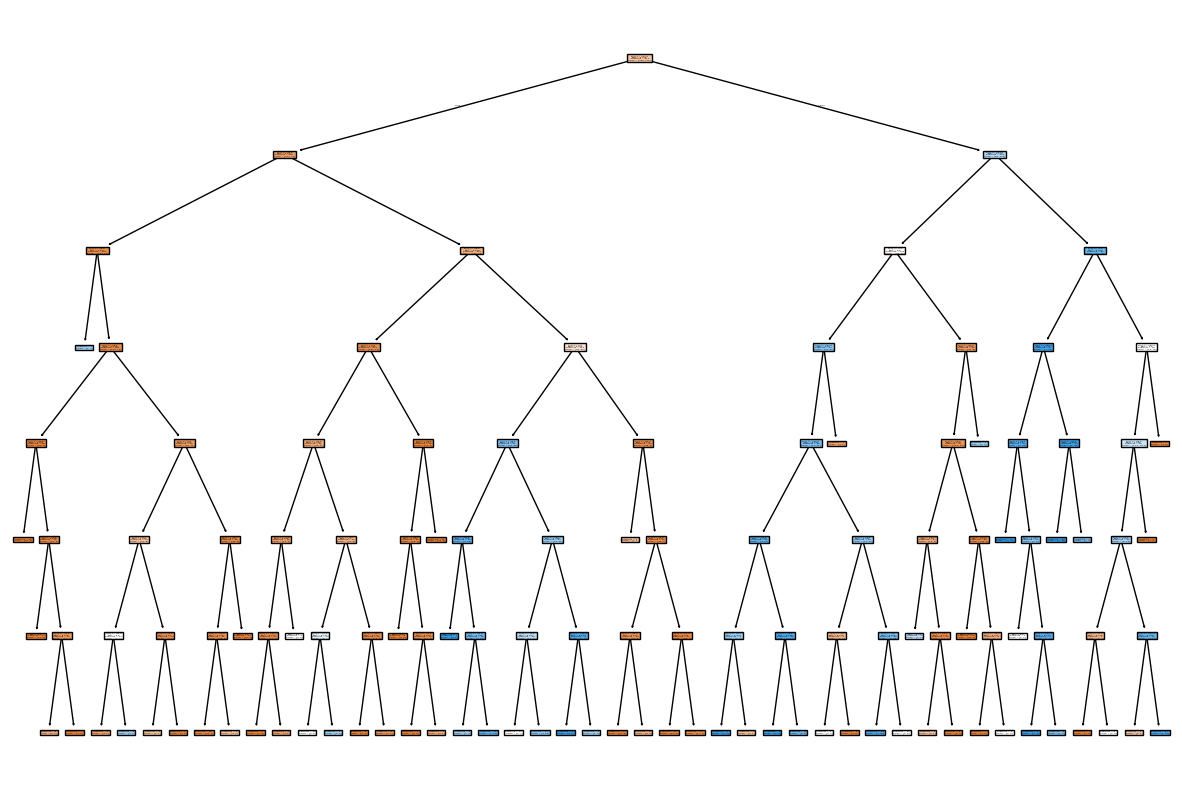

In [13]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtc,filled=True)
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=50,max_depth=4)     #n_estimator=50 means i want to make 50 decision tree
rfc.fit(x_train,y_train)
print(rfc.score(x_train, y_train))   # training data accuracy
print(rfc.score(x_test, y_test))    # test data accuracy

0.8892508143322475
0.8701298701298701
